In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from styleplot import style_plot
except ImportError:
    def style_plot(ax, title=None, xlabel=None, ylabel=None, grid=True,
                   remove_spines=True, title_size=14, label_size=11,
                   tick_size=9, title_weight="bold"):
        """Fallback plotting style so the notebook remains portable."""
        if title:
            ax.set_title(title, fontsize=title_size, fontweight=title_weight)
        if xlabel:
            ax.set_xlabel(xlabel, fontsize=label_size)
        if ylabel:
            ax.set_ylabel(ylabel, fontsize=label_size)
        ax.tick_params(axis="both", labelsize=tick_size)
        ax.grid(grid, alpha=0.25, linestyle="--")
        if remove_spines:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)


In [2]:
from styleplot import style_plot

# 0. __LOAD THE DATASET__

In [3]:
loans = pd.read_csv("prosper_loan.csv")

In [4]:
loans.head()

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,...,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
0,1021339766868145413AB3B,193129,2007-08-26 19:09:29.263000000,C,36,Completed,2009-08-14 00:00:00,0.16516,0.1580,0.1380,...,-133.18,0.0,0.0,0.0,0.0,1.0,0,0,0.0,258
1,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,0.12016,0.0920,0.0820,...,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
2,0EE9337825851032864889A,81716,2007-01-05 15:00:47.090000000,HR,36,Completed,2009-12-17 00:00:00,0.28269,0.2750,0.2400,...,-24.20,0.0,0.0,0.0,0.0,1.0,0,0,0.0,41
3,0EF5356002482715299901A,658116,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,0.12528,0.0974,0.0874,...,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158
4,0F023589499656230C5E3E2,909464,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,0.24614,0.2085,0.1985,...,-60.27,0.0,0.0,0.0,0.0,1.0,0,0,0.0,20


| Variable              | Meaning                           | Statistical role     |
| --------------------- | --------------------------------- | -------------------- |
| `ListingCreationDate` | Date loan listing was created     | Time variable        |
| `CreditGrade`         | Historical Prosper credit grade   | Credit risk          |
| `ProsperRating`       | Prosper's borrower rating         | Credit risk          |
| `Term`                | Loan term in months               | Explanatory variable |
| `LoanStatus`          | Current/Completed/Defaulted etc.  | Outcome              |
| `BorrowerAPR`         | Borrower's annual percentage rate | **Potential target** |
| `BorrowerRate`        | Borrower interest rate            | Financial outcome    |
| `LenderYield`         | Lender's yield                    | Financial outcome    |
| `LoanOriginalAmount`  | Original loan amount              | Financial variable   |
| `StatedMonthlyIncome` | Borrower's stated income          | Explanatory variable |
| `DebtToIncomeRatio`   | Debt-to-income ratio              | Credit risk          |
| `EmploymentStatus`    | Employment status                 | Explanatory variable |
| `IsBorrowerHomeowner` | Home ownership                    | Explanatory variable |
| `Investors`           | Number of investors               | Market participation |
| `PercentFunded`       | Percentage funded                 | Funding outcome      |


[Data Source](https://s3.amazonaws.com/udacity-hosted-downloads/ud651/prosperLoanData.csv)

# __Introduction__

## 1.1 __Business Problem__


Prosper is a peer-to-peer lending platform where borrowers receive loans from investors. 
The interest rate charged to a borrower is an important component of the lending process 
because it reflects the perceived risk of the borrower and affects the cost of borrowing.

Understanding the factors associated with borrower APR can help lenders and financial 
institutions better understand credit risk and loan pricing. It can also help identify 
which borrower and loan characteristics are most strongly associated with borrowing costs.

## 1.2 __Research Question__


> __What borrower and loan characteristics are associated with the interest rate charged to borrowers on the Prosper peer-to-peer lending platform?__

## 1.3 __Analytical Objectives__

The analysis aims to:

1. Understand the structure and quality of the Prosper loan dataset.
2. Explore the distribution of BorrowerAPR.
3. Investigate how borrower characteristics relate to BorrowerAPR.
4. Examine the relationship between credit risk and borrowing costs.
5. Quantify relationships between explanatory variables and BorrowerAPR.
6. Build and evaluate an interpretable statistical regression model.
7. Diagnose whether the regression assumptions are reasonably satisfied.
8. Compare statistical and machine-learning models.
9. Identify the most important predictors of BorrowerAPR.
10. Translate the statistical findings into practical financial insights.

# 2. __Dataset Understanding__

## 2.1 __Dataset Dimensions__

In [5]:
n_rows, n_columns = loans.shape

print(f"Number of observations: {n_rows:,}")
print(f"Number of variables: {n_columns:,}")

Number of observations: 113,937
Number of variables: 81


# 3. __Variable Definitions__

In [6]:
borrower_features = [
    "CreditGrade",
    "ProsperRating",
    "StatedMonthlyIncome",
    "DebtToIncomeRatio",
    "EmploymentStatus",
    "IsBorrowerHomeowner"
]

loan_features = [
    "Term",
    "LoanOriginalAmount"
]

time_features = [
    "ListingCreationDate"
]

potential_target = "BorrowerAPR"

In [7]:
print("Borrower features:")
print(borrower_features)

print("\nLoan features:")
print(loan_features)

print("\nTime features:")
print(time_features)

print("\nTarget:")
print(potential_target)

Borrower features:
['CreditGrade', 'ProsperRating', 'StatedMonthlyIncome', 'DebtToIncomeRatio', 'EmploymentStatus', 'IsBorrowerHomeowner']

Loan features:
['Term', 'LoanOriginalAmount']

Time features:
['ListingCreationDate']

Target:
BorrowerAPR


# 4. __Data Types__

In [8]:
dtype_summary = pd.DataFrame({
    "Data_Type": loans.dtypes.astype(str),
    "Missing_Count": loans.isna().sum(),
    "Missing_Percentage": loans.isna().mean().mul(100),
    "Unique_Values": loans.nunique()
})

dtype_summary.sort_values(
    "Missing_Percentage",
    ascending=False
)

,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
GroupKey,str,100596,88.290898,706
LoanFirstDefaultedCycleNumber,float64,96985,85.121602,43
ScorexChangeAtTimeOfListing,float64,95009,83.387311,372
ProsperPaymentsOneMonthPlusLate,float64,91852,80.616481,17
TotalProsperLoans,float64,91852,80.616481,9
...,...,...,...,...
PercentFunded,float64,0,0.000000,719
Recommendations,int64,0,0.000000,17
InvestmentFromFriendsCount,int64,0,0.000000,14
InvestmentFromFriendsAmount,float64,0,0.000000,726


# 5. __Missing Values__

In [9]:
missing_summary = (
    loans.isna()
    .sum()
    .to_frame("Missing_Count")
)

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Count"]
    .div(len(loans))
    .mul(100)
)

missing_summary = (
    missing_summary
    .sort_values("Missing_Percentage", ascending=False)
)

missing_summary

,Missing_Count,Missing_Percentage
GroupKey,100596,88.290898
LoanFirstDefaultedCycleNumber,96985,85.121602
ScorexChangeAtTimeOfListing,95009,83.387311
ProsperPaymentsOneMonthPlusLate,91852,80.616481
TotalProsperLoans,91852,80.616481
...,...,...
PercentFunded,0,0.000000
Recommendations,0,0.000000
InvestmentFromFriendsCount,0,0.000000
InvestmentFromFriendsAmount,0,0.000000


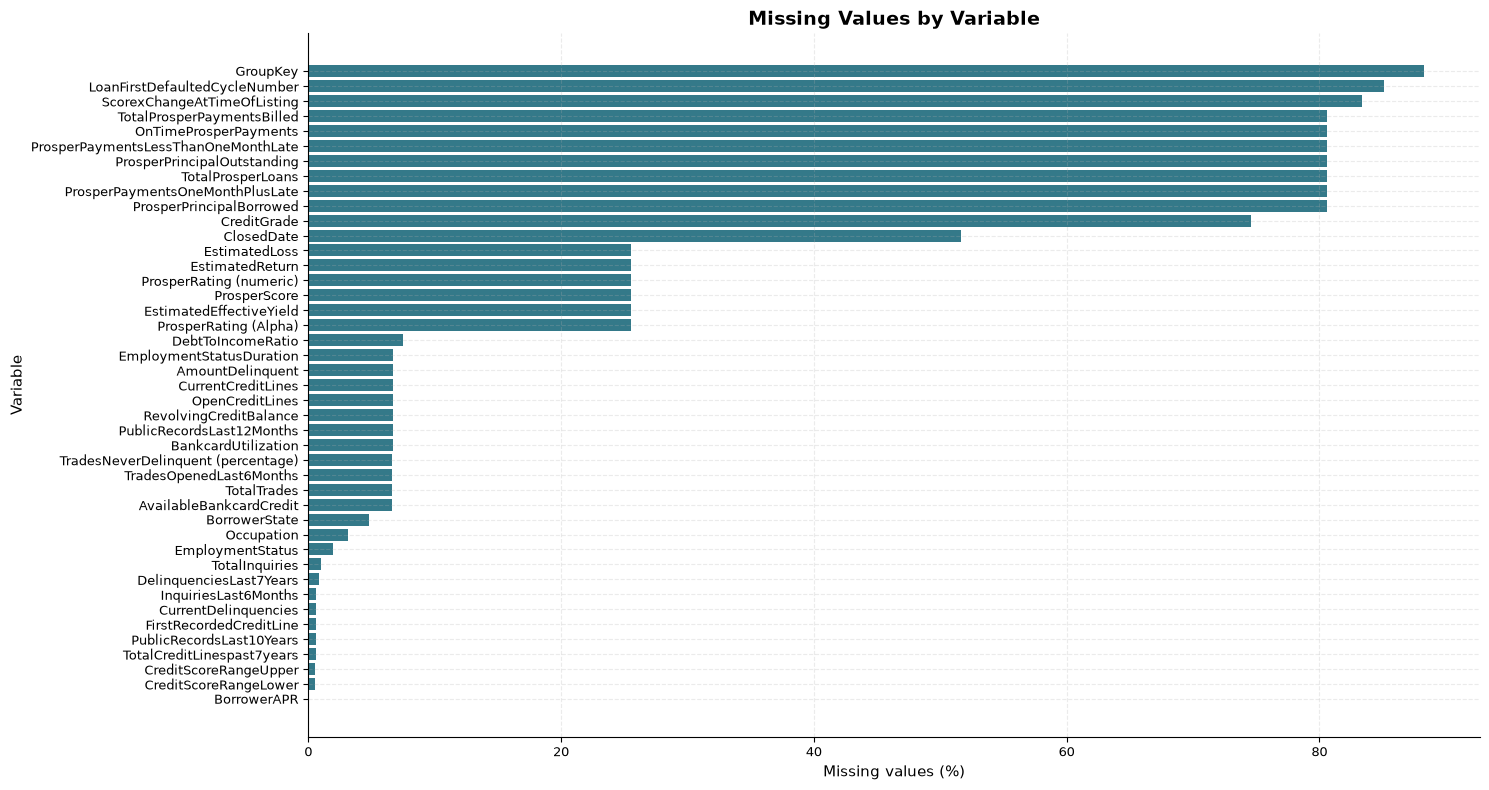

In [10]:
missing_plot = (
    missing_summary
    .query("Missing_Count > 0")
    .sort_values("Missing_Percentage")
)

fig, ax = plt.subplots(figsize=(15, 8))

ax.barh(
    missing_plot.index,
    missing_plot["Missing_Percentage"],
    color="#347989"
)

style_plot(
    ax,
    title = "Missing Values by Variable",
    xlabel = "Missing values (%)",
    ylabel = "Variable",
    grid = True
)

plt.tight_layout()
plt.show()

# 6.  __Check Duplicates__

In [11]:
duplicate_rows = loans.duplicated().sum()
duplicate_listing_keys = loans["ListingKey"].duplicated().sum()

print(f"Duplicate rows: {duplicate_rows:,}")
print(f"Duplicate ListingKey values: {duplicate_listing_keys:,}")

Duplicate rows: 0
Duplicate ListingKey values: 871


# 7. __Data Quality__

In [12]:
apr = loans["BorrowerAPR"]

print("Minimum APR:", apr.min())
print("Maximum APR:", apr.max())

Minimum APR: 0.00653
Maximum APR: 0.51229


In [13]:
invalid_apr = loans[
    (loans["BorrowerAPR"] < 0) |
    (loans["BorrowerAPR"] > 1)
]

print(f"Invalid APR records: {len(invalid_apr):,}")

Invalid APR records: 0


# 8. __Check Numerical Variables for Suspicious Values.__

In [14]:
numeric_columns = loans.select_dtypes("number").columns.to_list()

numeric_summary = loans[numeric_columns].describe().T
numeric_summary["missing"] = loans[numeric_columns].isna().sum()

numeric_summary

,count,mean,std,min,25%,50%,75%,max,missing
ListingNumber,113937.0,627885.692506,328076.236386,4.00000,400919.00000,600554.00000,892634.00000,1.255725e+06,0
Term,113937.0,40.830248,10.436212,12.00000,36.00000,36.00000,36.00000,6.000000e+01,0
BorrowerAPR,113912.0,0.218828,0.080364,0.00653,0.15629,0.20976,0.28381,5.122900e-01,25
BorrowerRate,113937.0,0.192764,0.074818,0.00000,0.13400,0.18400,0.25000,4.975000e-01,0
LenderYield,113937.0,0.182701,0.074516,-0.01000,0.12420,0.17300,0.24000,4.925000e-01,0
...,...,...,...,...,...,...,...,...,...
PercentFunded,113937.0,0.998584,0.017919,0.70000,1.00000,1.00000,1.00000,1.012500e+00,0
Recommendations,113937.0,0.048027,0.332353,0.00000,0.00000,0.00000,0.00000,3.900000e+01,0
InvestmentFromFriendsCount,113937.0,0.023460,0.232412,0.00000,0.00000,0.00000,0.00000,3.300000e+01,0
InvestmentFromFriendsAmount,113937.0,16.550751,294.545422,0.00000,0.00000,0.00000,0.00000,2.500000e+04,0


# 9. __Check Income__

- Income should not normally be negative.

In [15]:
negative_income = loans[
    loans["StatedMonthlyIncome"] < 0
]

print(f"Negative income records: {len(negative_income):,}")

Negative income records: 0


__Look for extreme income values__

In [16]:
print(
    loans["StatedMonthlyIncome"]
    .describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])
)

count    1.139370e+05
mean     5.608026e+03
std      7.478497e+03
min      0.000000e+00
1%       0.000000e+00
5%       1.541667e+03
25%      3.200333e+03
50%      4.666667e+03
75%      6.825000e+03
95%      1.225000e+04
99%      2.052667e+04
max      1.750003e+06
Name: StatedMonthlyIncome, dtype: float64


# 10. __Check DTI__

In [17]:
print(
    loans["DebtToIncomeRatio"]
    .describe(percentiles=[.01, .05, .25, .50, .75, .90, .95, .99])
)

count    105383.000000
mean          0.275947
std           0.551759
min           0.000000
1%            0.030000
5%            0.060000
25%           0.140000
50%           0.220000
75%           0.320000
90%           0.420000
95%           0.500000
99%           0.860000
max          10.010000
Name: DebtToIncomeRatio, dtype: float64


In [18]:
invalid_dti = loans[
    loans["DebtToIncomeRatio"] < 0
]

print(f"Negative DTI values: {len(invalid_dti):,}")

Negative DTI values: 0


# 11. __Outliers__

In [19]:
def outlier_summary(df, columns):
    results = []

    for column in columns:
        series = df[column].dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        count = ((series < lower) | (series > upper)).sum()

        results.append({
            "Variable": column,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower_Bound": lower,
            "Upper_Bound": upper,
            "Outlier_Count": count,
            "Outlier_Percentage": count / len(series) * 100
        })

    return pd.DataFrame(results)

In [20]:
outlier_summary(
    loans,
    [
        "BorrowerAPR",
        "StatedMonthlyIncome",
        "DebtToIncomeRatio",
        "LoanOriginalAmount"
    ]
)

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,BorrowerAPR,0.156290,0.28381,0.127520,-0.034990,0.475090,3,0.002634
1,StatedMonthlyIncome,3200.333333,6825.00000,3624.666667,-2236.666668,12262.000001,5676,4.981700
2,DebtToIncomeRatio,0.140000,0.32000,0.180000,-0.130000,0.590000,2694,2.556390
3,LoanOriginalAmount,4000.000000,12000.00000,8000.000000,-8000.000000,24000.000000,4395,3.857395


# 12. __Exploratory Data Analysis__

## 12.1 __Borrower APR Distribution__

In [21]:
apr = loans["BorrowerAPR"].dropna()

print(apr.describe())

print(f"\nSkewness: {apr.skew():.3f}")
print(f"Kurtosis: {apr.kurtosis():.3f}")

count    113912.000000
mean          0.218828
std           0.080364
min           0.006530
25%           0.156290
50%           0.209760
75%           0.283810
max           0.512290
Name: BorrowerAPR, dtype: float64

Skewness: 0.224
Kurtosis: -0.879


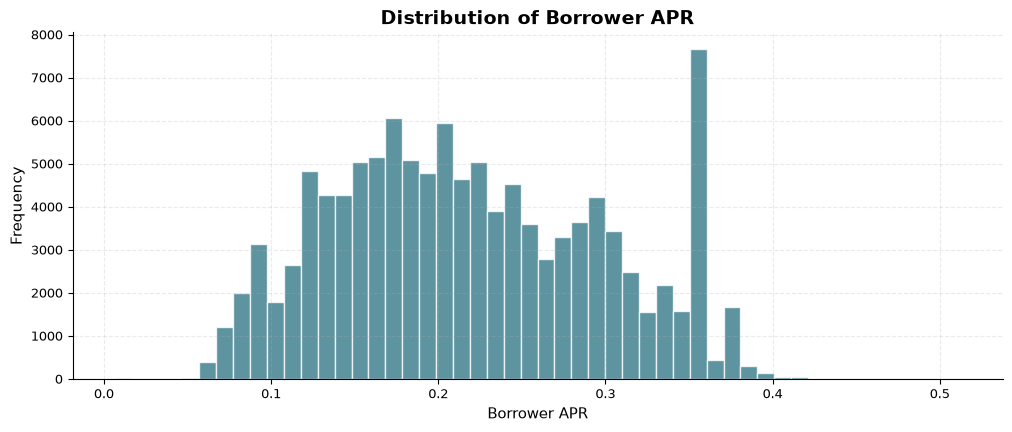

In [22]:
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.hist(
    apr,
    bins=50,
    color = "#347989",
    alpha = 0.8,
    edgecolor="white"
)


style_plot(
    ax,
    title = "Distribution of Borrower APR",
    xlabel = "Borrower APR",
    ylabel = "Frequency",
    grid = True
)
plt.show()

# 13. __Box Plot__

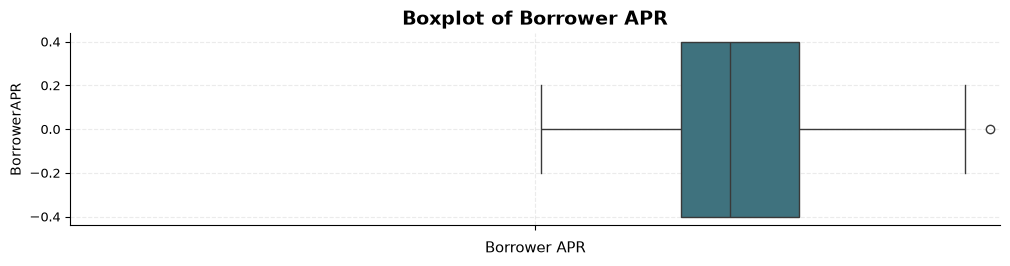

In [23]:
fig, ax = plt.subplots(figsize=(12, 2.5))

sns.boxplot(
    apr,
    ax = ax,
    orientation = "horizontal",
    color = "#347989"
)

style_plot(
    ax,
    title="Boxplot of Borrower APR",
    xlabel="Borrower APR",
    ylabel=""
)

plt.show()

# 14. __Time Analysis__

In [24]:
loans["ListingCreationDate"] = pd.to_datetime(
    loans["ListingCreationDate"],
    errors="coerce"
)

In [25]:
loans["ListingYear"] = loans["ListingCreationDate"].dt.year
loans["ListingMonth"] = loans["ListingCreationDate"].dt.month
loans["ListingQuarter"] = loans["ListingCreationDate"].dt.to_period("Q")

In [26]:
loans["ListingCreationDate"].describe()

count                           113550
mean     2011-07-09 15:18:33.127323648
min         2005-11-09 20:44:28.847000
25%      2008-09-19 20:21:12.676499968
50%      2012-06-16 12:33:55.665000192
75%      2013-09-10 06:24:16.660250112
max         2014-03-10 12:20:53.760000
Name: ListingCreationDate, dtype: object

# 15. __Numbers of Loans Over Time__

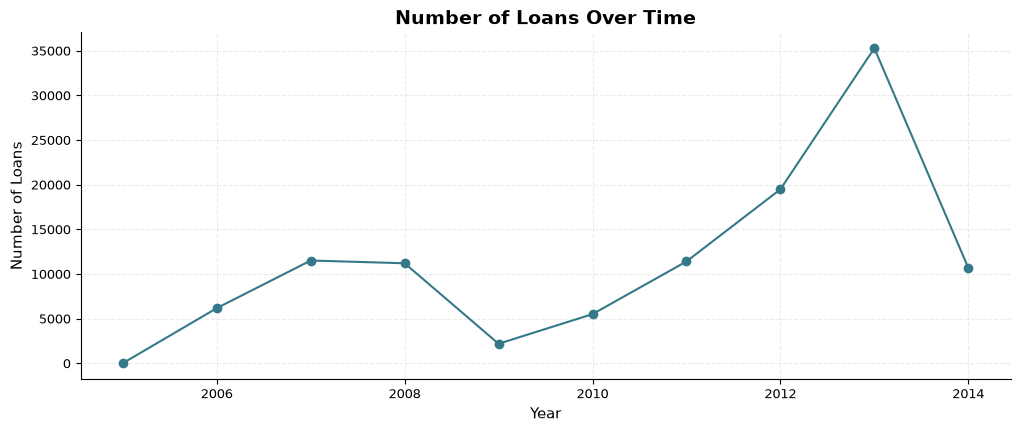

In [27]:
loan_counts = (
    loans
    .groupby("ListingYear")
    .size()
)

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(
    loan_counts.index,
    loan_counts.values,
    marker="o",
    color = "#347989"
)

style_plot(
    ax,
    title="Number of Loans Over Time",
    xlabel="Year",
    ylabel="Number of Loans"
)

plt.show()

# 16. __Average APR Over Time__

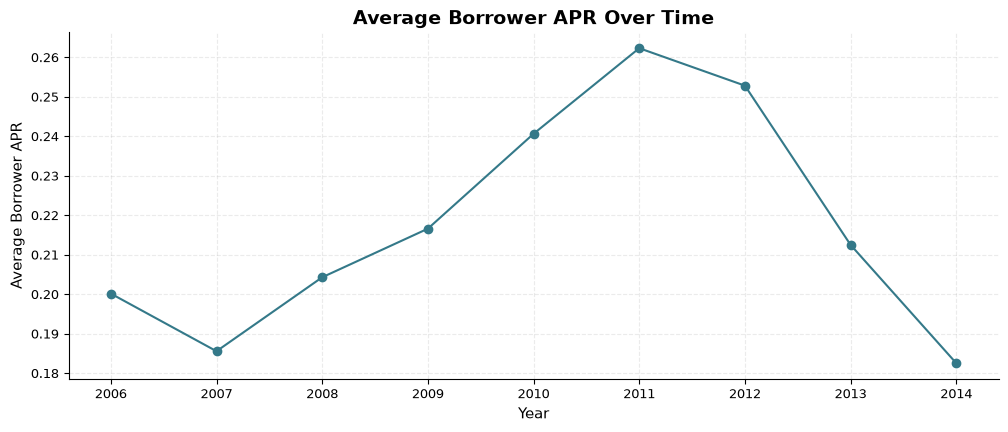

In [28]:
annual_apr = (
    loans
    .groupby("ListingYear")["BorrowerAPR"]
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(
    annual_apr.index,
    annual_apr.values,
    marker="o",
    color = "#347989"
)

style_plot(
    ax,
    title="Average Borrower APR Over Time",
    xlabel="Year",
    ylabel="Average Borrower APR"
)

plt.show()

__Insights:__
- **The time-series plot shows APR rising from 2007 through roughly 2011 and then falling considerably through 2014.**
- __This suggests that pricing is not purely borrower-specific; market/platform/time effects also matter.__

In [29]:
print(loans.columns.to_list())

['ListingKey', 'ListingNumber', 'ListingCreationDate', 'CreditGrade', 'Term', 'LoanStatus', 'ClosedDate', 'BorrowerAPR', 'BorrowerRate', 'LenderYield', 'EstimatedEffectiveYield', 'EstimatedLoss', 'EstimatedReturn', 'ProsperRating (numeric)', 'ProsperRating (Alpha)', 'ProsperScore', 'ListingCategory (numeric)', 'BorrowerState', 'Occupation', 'EmploymentStatus', 'EmploymentStatusDuration', 'IsBorrowerHomeowner', 'CurrentlyInGroup', 'GroupKey', 'DateCreditPulled', 'CreditScoreRangeLower', 'CreditScoreRangeUpper', 'FirstRecordedCreditLine', 'CurrentCreditLines', 'OpenCreditLines', 'TotalCreditLinespast7years', 'OpenRevolvingAccounts', 'OpenRevolvingMonthlyPayment', 'InquiriesLast6Months', 'TotalInquiries', 'CurrentDelinquencies', 'AmountDelinquent', 'DelinquenciesLast7Years', 'PublicRecordsLast10Years', 'PublicRecordsLast12Months', 'RevolvingCreditBalance', 'BankcardUtilization', 'AvailableBankcardCredit', 'TotalTrades', 'TradesNeverDelinquent (percentage)', 'TradesOpenedLast6Months', 'Deb

# 17. __Credit Rating__

In [30]:
loans = loans.rename(columns = {'ProsperRating (numeric)': "ProsperRating"})

loans["ProsperRating"].value_counts(dropna=False)

ProsperRating
NaN    29084
4.0    18345
5.0    15581
6.0    14551
3.0    14274
2.0     9795
1.0     6935
7.0     5372
Name: count, dtype: int64

In [31]:
rating_summary = (
    loans
    .groupby("ProsperRating", dropna=False)["BorrowerAPR"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std"
    )
    .sort_values("Mean")
)

rating_summary

,Count,Mean,Median,Std
ProsperRating,,,,
7.0,5372,0.090041,0.09000,0.016905
6.0,14551,0.138909,0.13799,0.016361
5.0,15581,0.184030,0.18173,0.018343
NaN,29059,0.195962,0.18224,0.077243
4.0,18345,0.226124,0.22362,0.023306
3.0,14274,0.280581,0.28488,0.024580
2.0,9795,0.330551,0.33215,0.024768
1.0,6935,0.356061,0.35797,0.019608


# 18. __APR By ProsPerRating__

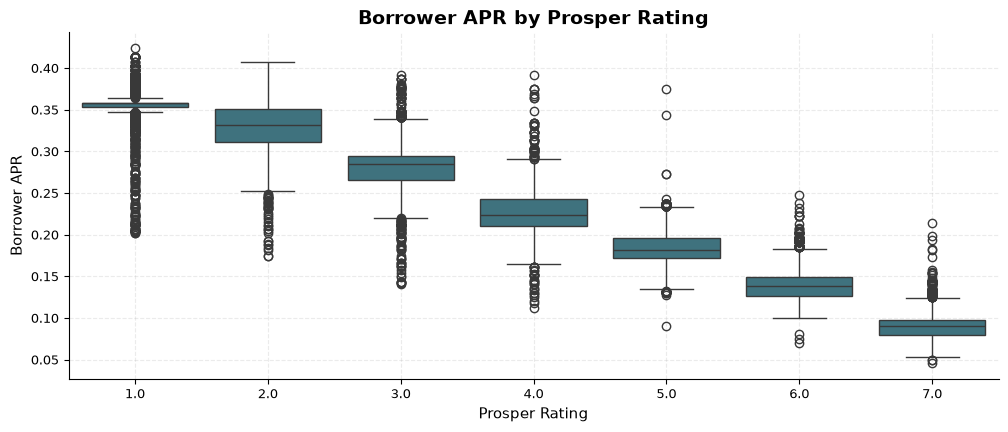

In [32]:
fig, ax = plt.subplots(figsize=(12, 4.5))

sns.boxplot(
    data=loans,
    x="ProsperRating",
    y="BorrowerAPR",
    ax=ax,
    color = "#347989"
)

style_plot(
    ax,
    title="Borrower APR by Prosper Rating",
    xlabel="Prosper Rating",
    ylabel="Borrower APR"
)

plt.show()

__Insight:__
> **The APR boxplot shows a very clear monotonic decrease in APR as Prosper Rating improves.**

# 19. __CreditGrade__

In [33]:
credit_summary = (
    loans
    .groupby("CreditGrade", dropna=False)["BorrowerAPR"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std"
    )
    .sort_values("Mean")
)

credit_summary

,Count,Mean,Median,Std
CreditGrade,,,,
AA,3495,0.106188,0.096880,0.032743
A,3314,0.135699,0.125520,0.042928
B,4387,0.164337,0.156020,0.044285
C,5646,0.193455,0.180440,0.058419
D,5152,0.225526,0.213975,0.061297
NaN,84984,0.226597,0.219450,0.079947
NC,140,0.235015,0.241260,0.056230
E,3288,0.270713,0.269135,0.058386
HR,3506,0.271261,0.281790,0.067572


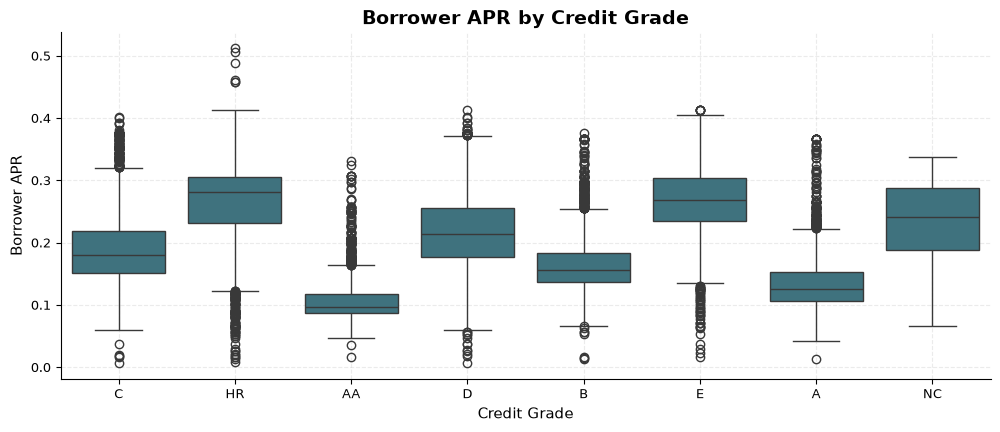

In [34]:
fig, ax = plt.subplots(figsize=(12, 4.5))

sns.boxplot(
    data=loans,
    x="CreditGrade",
    y="BorrowerAPR",
    ax=ax,
    color = "#347989"
)

style_plot(
    ax,
    title="Borrower APR by Credit Grade",
    xlabel="Credit Grade",
    ylabel="Borrower APR"
)

plt.show()

# 20. __Income__

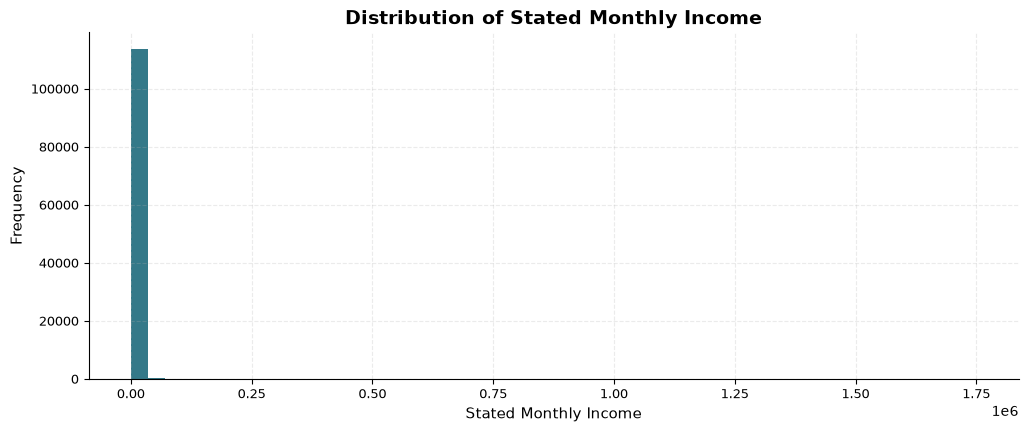

In [35]:
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.hist(
    loans["StatedMonthlyIncome"].dropna(),
    bins=50,
    color="#347989"
)

style_plot(
    ax,
    title="Distribution of Stated Monthly Income",
    xlabel="Stated Monthly Income",
    ylabel="Frequency"
)

plt.show()

# 21. __Log Income__

In [36]:
loans["LogMonthlyIncome"] = np.log1p(
    loans["StatedMonthlyIncome"]
)

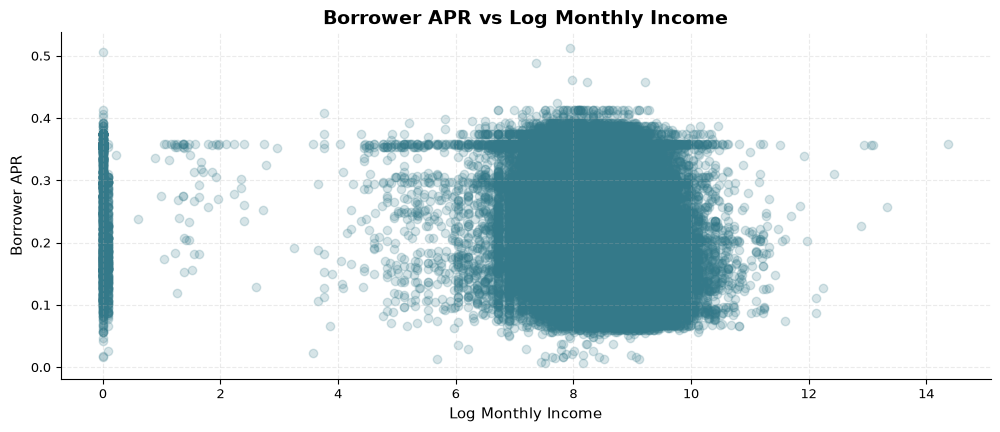

In [37]:
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.scatter(
    loans["LogMonthlyIncome"],
    loans["BorrowerAPR"],
    alpha=0.2,
    color = "#347989"
)

style_plot(
    ax,
    title="Borrower APR vs Log Monthly Income",
    xlabel="Log Monthly Income",
    ylabel="Borrower APR"
)

plt.show()

# 22. __DebtToIncomeRatio__

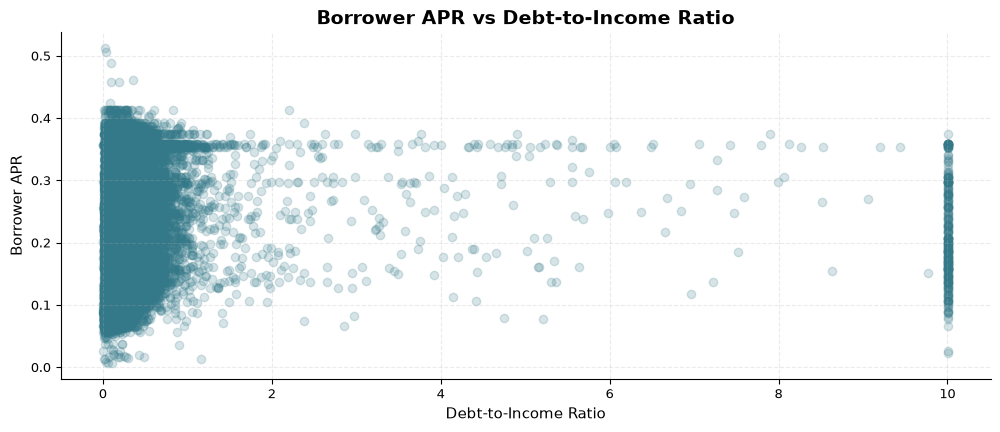

In [38]:
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.scatter(
    loans["DebtToIncomeRatio"],
    loans["BorrowerAPR"],
    alpha=0.2,
    color = "#347989"
)

style_plot(
    ax,
    title="Borrower APR vs Debt-to-Income Ratio",
    xlabel="Debt-to-Income Ratio",
    ylabel="Borrower APR"
)

plt.show()

# 23. __DebtToIncomeRatio Using Bins__

- For easier interpretation

In [39]:
loans["DTI_Group"] = pd.qcut(
    loans["DebtToIncomeRatio"],
    q=5,
    duplicates="drop"
)

In [40]:
dti_summary = (
    loans
    .groupby("DTI_Group", observed=True)["BorrowerAPR"]
    .agg(["count", "mean", "median"])
)

dti_summary

,count,mean,median
DTI_Group,,,
"(-0.001, 0.13]",23059,0.203087,0.195010
"(0.13, 0.19]",21676,0.207181,0.196450
"(0.19, 0.25]",19202,0.212274,0.200615
"(0.25, 0.34]",20816,0.218449,0.207350
"(0.34, 10.01]",20605,0.241959,0.234980


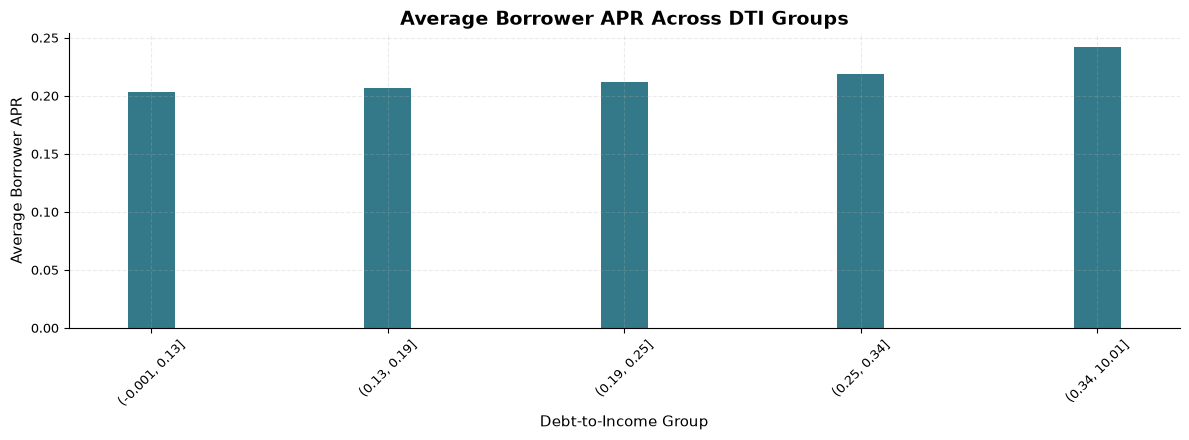

In [41]:
fig, ax = plt.subplots(figsize=(12, 4.5))

dti_summary["mean"].plot(
    kind="bar",
    ax=ax,
    color = "#347989",
    width = 0.2
)

style_plot(
    ax,
    title="Average Borrower APR Across DTI Groups",
    xlabel="Debt-to-Income Group",
    ylabel="Average Borrower APR"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 24. __Loan Amount__

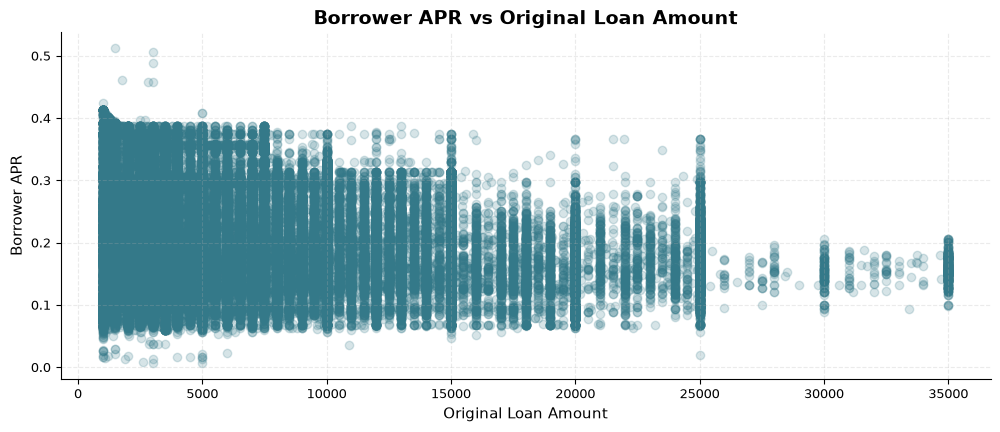

In [42]:
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.scatter(
    loans["LoanOriginalAmount"],
    loans["BorrowerAPR"],
    alpha=0.2,
    color = "#347989"  
)

style_plot(
    ax,
    title="Borrower APR vs Original Loan Amount",
    xlabel="Original Loan Amount",
    ylabel="Borrower APR"
)

plt.show()

# 25. __Term__

In [43]:
loans["Term"].value_counts().sort_index()

Term
12     1614
36    87778
60    24545
Name: count, dtype: int64

In [44]:
term_summary = (
    loans
    .groupby("Term")["BorrowerAPR"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std"
    )
)

term_summary

,Count,Mean,Median,Std
Term,,,,
12,1614,0.216223,0.22189,0.090236
36,87753,0.219431,0.20976,0.085489
60,24545,0.216843,0.20931,0.057479


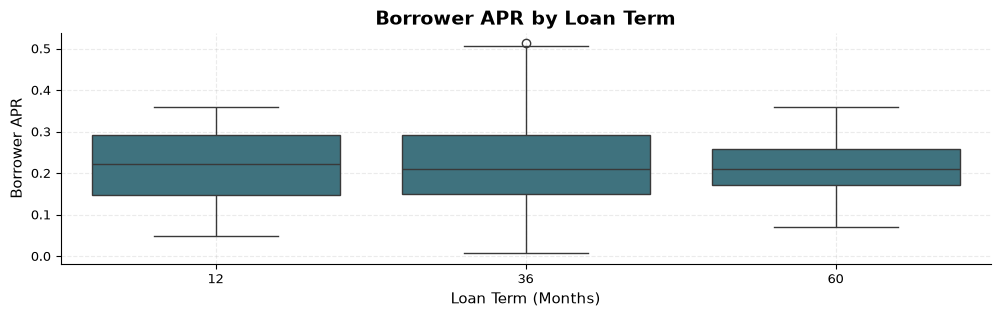

In [45]:
fig, ax = plt.subplots(figsize=(12, 3))

sns.boxplot(
    data=loans,
    x="Term",
    y="BorrowerAPR",
    ax=ax,
    color = "#347989"
)

style_plot(
    ax,
    title="Borrower APR by Loan Term",
    xlabel="Loan Term (Months)",
    ylabel="Borrower APR"
)

plt.show()

# 26. __Employment__

In [46]:
loans["EmploymentStatus"].value_counts(dropna=False)

EmploymentStatus
Employed         67322
Full-time        26355
Self-employed     6134
Not available     5347
Other             3806
NaN               2255
Part-time         1088
Not employed       835
Retired            795
Name: count, dtype: int64

In [47]:
employment_summary = (
    loans
    .groupby("EmploymentStatus", dropna=False)["BorrowerAPR"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median"
    )
    .sort_values("Mean")
)

employment_summary

,Count,Mean,Median
EmploymentStatus,,,
NaN,2230,0.195672,0.18824
Not available,5347,0.200607,0.19981
Part-time,1088,0.202211,0.18294
Full-time,26355,0.204604,0.18726
Retired,795,0.215450,0.20011
Employed,67322,0.223558,0.21434
Self-employed,6134,0.230295,0.21761
Other,3806,0.247302,0.24466
Not employed,835,0.275757,0.29510


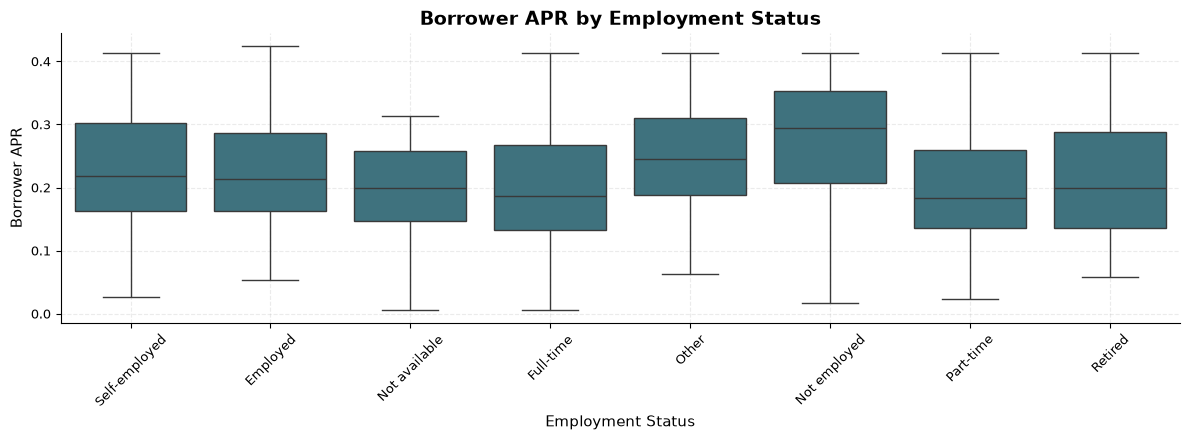

In [48]:
fig, ax = plt.subplots(figsize=(12, 4.5))

sns.boxplot(
    data=loans,
    x="EmploymentStatus",
    y="BorrowerAPR",
    ax=ax,
    color = "#347989"
)

style_plot(
    ax,
    title="Borrower APR by Employment Status",
    xlabel="Employment Status",
    ylabel="Borrower APR"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 27. __HomeOwnerShip__

In [49]:
homeowner_summary = (
    loans
    .groupby("IsBorrowerHomeowner")["BorrowerAPR"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std"
    )
)

homeowner_summary

,Count,Mean,Median,Std
IsBorrowerHomeowner,,,,
False,56434,0.229600,0.22362,0.078427
True,57478,0.208251,0.19645,0.080838


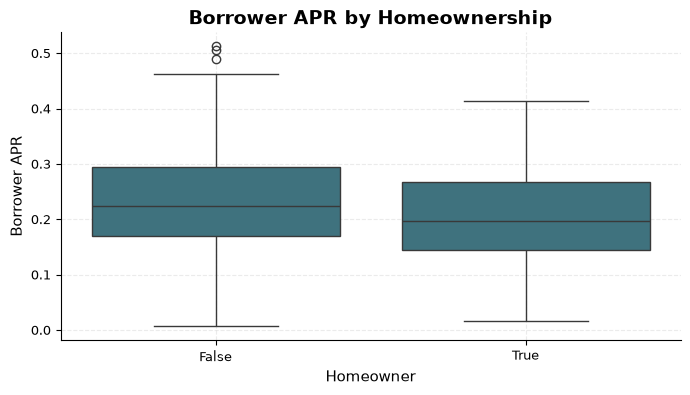

In [50]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.boxplot(
    data=loans,
    x="IsBorrowerHomeowner",
    y="BorrowerAPR",
    ax=ax,
    color = "#347989"
)

style_plot(
    ax,
    title="Borrower APR by Homeownership",
    xlabel="Homeowner",
    ylabel="Borrower APR"
)

plt.show()

# 28. __Bivariate Analysis__

In [51]:
correlation_features = [
    "BorrowerAPR",
    "StatedMonthlyIncome",
    "DebtToIncomeRatio",
    "LoanOriginalAmount",
    "Term",
    "Investors",
    "PercentFunded"
]

In [52]:
corr = loans[correlation_features].corr()

corr

,BorrowerAPR,StatedMonthlyIncome,DebtToIncomeRatio,LoanOriginalAmount,Term,Investors,PercentFunded
BorrowerAPR,1.000000,-0.082338,0.056327,-0.322887,-0.011183,-0.307606,-0.028236
StatedMonthlyIncome,-0.082338,1.000000,-0.122659,0.201259,0.028479,0.076244,-0.012895
DebtToIncomeRatio,0.056327,-0.122659,1.000000,0.010112,-0.014670,0.004095,0.002319
LoanOriginalAmount,-0.322887,0.201259,0.010112,1.000000,0.338927,0.380093,-0.010248
Term,-0.011183,0.028479,-0.014670,0.338927,1.000000,-0.045137,-0.028806
Investors,-0.307606,0.076244,0.004095,0.380093,-0.045137,1.000000,-0.049716
PercentFunded,-0.028236,-0.012895,0.002319,-0.010248,-0.028806,-0.049716,1.000000


In [53]:
# Custom soft sage green sequential palette
custom_cmap = sns.light_palette("#347989", as_cmap=True)

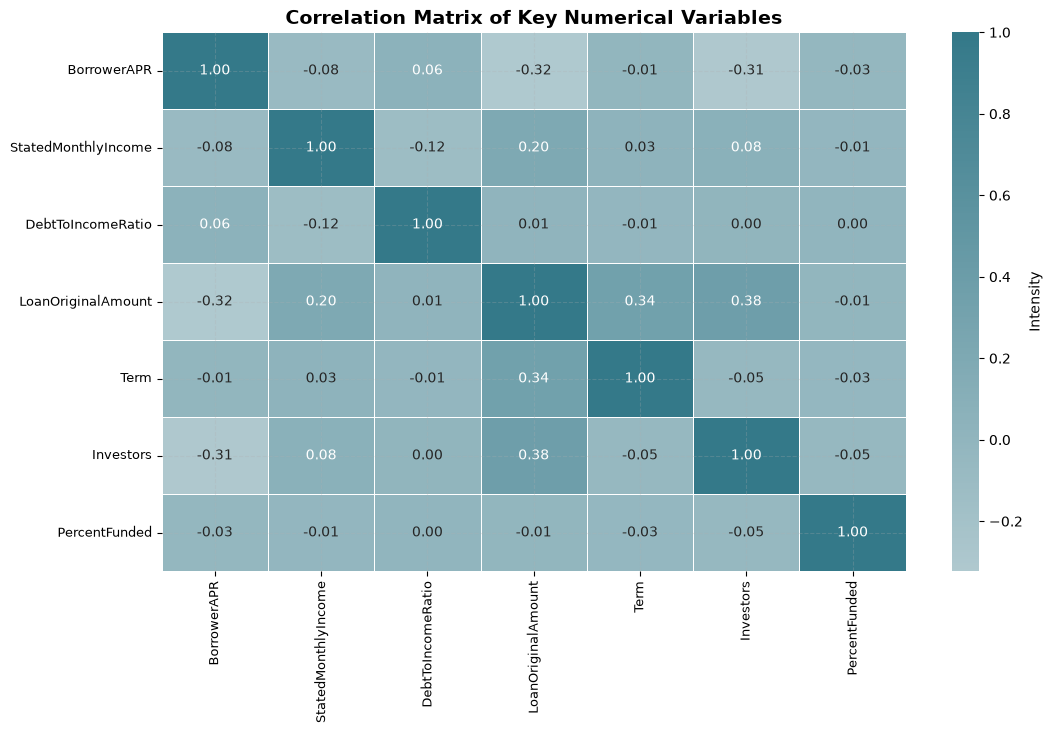

In [54]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Intensity"},
    ax=ax
)

style_plot(
    ax,
    title="Correlation Matrix of Key Numerical Variables",
    xlabel="",
    ylabel=""
)

plt.show()

# 29. __Pearson and Spearman Correlation__

In [55]:
from scipy.stats import pearsonr, spearmanr

In [56]:
def correlation_tests(df, target, features):
    results = []

    for feature in features:
        data = df[[target, feature]].dropna()

        pearson_r, pearson_p = pearsonr(
            data[target],
            data[feature]
        )

        spearman_r, spearman_p = spearmanr(
            data[target],
            data[feature]
        )

        results.append({
            "Feature": feature,
            "Pearson_r": pearson_r,
            "Pearson_p": pearson_p,
            "Spearman_r": spearman_r,
            "Spearman_p": spearman_p
        })

    return pd.DataFrame(results)

In [57]:
correlation_tests(
    loans,
    "BorrowerAPR",
    [
        "StatedMonthlyIncome",
        "DebtToIncomeRatio",
        "LoanOriginalAmount",
        "Term"
    ]
)

,Feature,Pearson_r,Pearson_p,Spearman_r,Spearman_p
0,StatedMonthlyIncome,-0.082338,1.551461e-170,-0.196883,0.000000
1,DebtToIncomeRatio,0.056327,8.652518e-75,0.167961,0.000000
2,LoanOriginalAmount,-0.322887,0.000000e+00,-0.313359,0.000000
3,Term,-0.011183,1.602694e-04,0.006264,0.034488


# 30. __Statistical Test__

__Homeowner vs non-homeowner__

In [58]:
from scipy.stats import ttest_ind

In [59]:
homeowner = loans.loc[
    loans["IsBorrowerHomeowner"] == True,
    "BorrowerAPR"
].dropna()

non_homeowner = loans.loc[
    loans["IsBorrowerHomeowner"] == False,
    "BorrowerAPR"
].dropna()

t_stat, p_value = ttest_ind(
    homeowner,
    non_homeowner,
    equal_var=False
)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

t-statistic: -45.2417
p-value: 0.000000


p < 0.05
- There is evidence of a statistically significant difference

# 31. __ProsperRating Statistical Test__

> Because there are multiple rating groups, we will use ANOVA.

In [60]:
from scipy.stats import f_oneway

In [61]:
rating_groups = [
    group["BorrowerAPR"].dropna()
    for _, group in loans.groupby("ProsperRating")
]

f_stat, p_value = f_oneway(*rating_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.6f}")

F-statistic: 187876.2535
p-value: 0.000000


> The evidence is pointing to at least one rating group has a different mean APR

# 32. __Features Engineering__

In [62]:
loans["ListingDayOfWeek"] = (
    loans["ListingCreationDate"]
    .dt.dayofweek
)

# 33. __Log Transformation__

In [63]:
loans["LogMonthlyIncome"] = np.log1p(
    loans["StatedMonthlyIncome"]
)

In [64]:
loans["LogLoanAmount"] = np.log1p(
    loans["LoanOriginalAmount"]
)

In [65]:
loans[
    [
        "StatedMonthlyIncome",
        "LogMonthlyIncome",
        "LoanOriginalAmount",
        "LogLoanAmount"
    ]
].describe()

,StatedMonthlyIncome,LogMonthlyIncome,LoanOriginalAmount,LogLoanAmount
count,1.139370e+05,113937.000000,113937.00000,113937.000000
mean,5.608026e+03,8.326333,8337.01385,8.738831
std,7.478497e+03,1.193560,6245.80058,0.795616
min,0.000000e+00,0.000000,1000.00000,6.908755
25%,3.200333e+03,8.071323,4000.00000,8.294300
50%,4.666667e+03,8.448415,6500.00000,8.779711
75%,6.825000e+03,8.828494,12000.00000,9.392745
max,1.750003e+06,14.375129,35000.00000,10.463132


> Let us start we few variables.

In [66]:
# Check how many complete non-null rows will actually be used
cols = [
    "BorrowerAPR",
    "ProsperRating",
    "Term",
    "LogMonthlyIncome",
    "DebtToIncomeRatio",
    "LogLoanAmount",
    "EmploymentStatus",
    "IsBorrowerHomeowner",
]
model_data = loans[cols].dropna()

print("Fitted Sample Size:", len(model_data))
print("Unique BorrowerAPR Values:", model_data["BorrowerAPR"].nunique())
print("BorrowerAPR Variance:", model_data["BorrowerAPR"].var())

Fitted Sample Size: 77557
Unique BorrowerAPR Values: 2174
BorrowerAPR Variance: 0.0062663073119525094


In [67]:
# Keep the OLS sample definition explicit: use complete cases for the statistical model.

print("Missing values in OLS variables:")
print(loans[cols].isna().sum())

model_data = loans[cols].dropna().copy()
print(f"Complete-case OLS sample: {len(model_data):,}")


Missing values in OLS variables:
BorrowerAPR               25
ProsperRating          29084
Term                       0
LogMonthlyIncome           0
DebtToIncomeRatio       8554
LogLoanAmount              0
EmploymentStatus        2255
IsBorrowerHomeowner        0
dtype: int64
Complete-case OLS sample: 77,557


# 34. __OLS Model__

In [68]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [69]:
ols_formula = """
BorrowerAPR ~
C(ProsperRating) +
Term +
LogMonthlyIncome +
DebtToIncomeRatio +
LogLoanAmount +
C(EmploymentStatus) +
IsBorrowerHomeowner
"""

In [70]:
ols = smf.ols(
    formula=ols_formula,
    data=model_data
).fit()

In [71]:
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:            BorrowerAPR   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                 6.092e+04
Date:                Sun, 16 Aug 2026   Prob (F-statistic):               0.00
Time:                        13:36:34   Log-Likelihood:             1.8997e+05
No. Observations:               77557   AIC:                        -3.799e+05
Df Residuals:                   77539   BIC:                        -3.797e+05
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


# 35. __Extract coefficients__

In [72]:
coef_table = pd.DataFrame({
    "Coefficient": ols.params,
    "Std_Error": ols.bse,
    "t_stat": ols.tvalues,
    "p_value": ols.pvalues,
    "CI_Lower": ols.conf_int()[0],
    "CI_Upper": ols.conf_int()[1]
})

coef_table

,Coefficient,Std_Error,t_stat,p_value,CI_Lower,CI_Upper
Intercept,0.373451,0.001444,258.589818,0.000000e+00,0.370620,0.376282
C(ProsperRating)[T.2.0],-0.026359,0.000359,-73.474972,0.000000e+00,-0.027062,-0.025656
C(ProsperRating)[T.3.0],-0.075573,0.000342,-221.048175,0.000000e+00,-0.076243,-0.074903
C(ProsperRating)[T.4.0],-0.129374,0.000342,-378.741898,0.000000e+00,-0.130043,-0.128704
C(ProsperRating)[T.5.0],-0.170898,0.000352,-486.031741,0.000000e+00,-0.171587,-0.170208
C(ProsperRating)[T.6.0],-0.215752,0.000354,-608.834629,0.000000e+00,-0.216446,-0.215057
C(ProsperRating)[T.7.0],-0.264343,0.000425,-621.522727,0.000000e+00,-0.265176,-0.263509
C(EmploymentStatus)[T.Full-time],-0.000912,0.000265,-3.439717,5.826291e-04,-0.001432,-0.000392
C(EmploymentStatus)[T.Not employed],0.004287,0.020897,0.205151,8.374547e-01,-0.036671,0.045244
C(EmploymentStatus)[T.Other],-0.002055,0.000369,-5.568542,2.577275e-08,-0.002778,-0.001331


In [73]:
coef_table.sort_values(
    "p_value"
)

,Coefficient,Std_Error,t_stat,p_value,CI_Lower,CI_Upper
Intercept,0.373451,0.001444,258.589818,0.000000e+00,0.370620,0.376282
C(ProsperRating)[T.2.0],-0.026359,0.000359,-73.474972,0.000000e+00,-0.027062,-0.025656
C(ProsperRating)[T.3.0],-0.075573,0.000342,-221.048175,0.000000e+00,-0.076243,-0.074903
C(ProsperRating)[T.4.0],-0.129374,0.000342,-378.741898,0.000000e+00,-0.130043,-0.128704
C(ProsperRating)[T.5.0],-0.170898,0.000352,-486.031741,0.000000e+00,-0.171587,-0.170208
C(ProsperRating)[T.6.0],-0.215752,0.000354,-608.834629,0.000000e+00,-0.216446,-0.215057
C(ProsperRating)[T.7.0],-0.264343,0.000425,-621.522727,0.000000e+00,-0.265176,-0.263509
LogLoanAmount,-0.001767,0.000139,-12.741174,3.804132e-37,-0.002039,-0.001496
Term,0.000079,0.000007,11.080176,1.644827e-28,0.000065,0.000093
C(EmploymentStatus)[T.Other],-0.002055,0.000369,-5.568542,2.577275e-08,-0.002778,-0.001331


# 36. __Confidence Interval__

In [74]:
confidence_intervals = ols.conf_int()

confidence_intervals.columns = [
    "Lower_95%",
    "Upper_95%"
]

confidence_intervals

,Lower_95%,Upper_95%
Intercept,0.370620,0.376282
C(ProsperRating)[T.2.0],-0.027062,-0.025656
C(ProsperRating)[T.3.0],-0.076243,-0.074903
C(ProsperRating)[T.4.0],-0.130043,-0.128704
C(ProsperRating)[T.5.0],-0.171587,-0.170208
C(ProsperRating)[T.6.0],-0.216446,-0.215057
C(ProsperRating)[T.7.0],-0.265176,-0.263509
C(EmploymentStatus)[T.Full-time],-0.001432,-0.000392
C(EmploymentStatus)[T.Not employed],-0.036671,0.045244
C(EmploymentStatus)[T.Other],-0.002778,-0.001331


# 37. __Regression Diagnostics__

## 37.1 __Predictions and Residuals__

In [75]:
model_data["Fitted"] = ols.fittedvalues
model_data["Residuals"] = ols.resid

__Linearity__

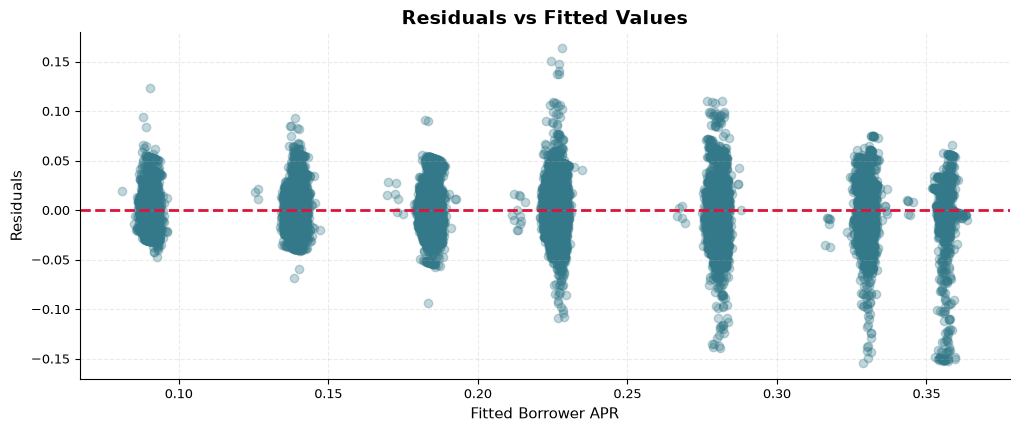

In [76]:
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.scatter(
    model_data["Fitted"],
    model_data["Residuals"],
    alpha=0.3,
    color = "#347989"
)

ax.axhline(
    0,
    color="crimson",
    linestyle="--",
    lw = 2
)

style_plot(
    ax,
    title="Residuals vs Fitted Values",
    xlabel="Fitted Borrower APR",
    ylabel="Residuals"
)

plt.show()

__Homoscedasticity — Breusch-Pagan__

In [77]:
from statsmodels.stats.diagnostic import het_breuschpagan

In [78]:
bp_test = het_breuschpagan(
    ols.resid,
    ols.model.exog
)

bp_results = pd.Series(
    bp_test,
    index=[
        "LM Statistic",
        "LM p-value",
        "F Statistic",
        "F p-value"
    ]
)

bp_results

LM Statistic    5486.056347
LM p-value         0.000000
F Statistic      347.193295
F p-value          0.000000
dtype: float64

__Normality — Q-Q plot__

In [79]:
import statsmodels.api as sm

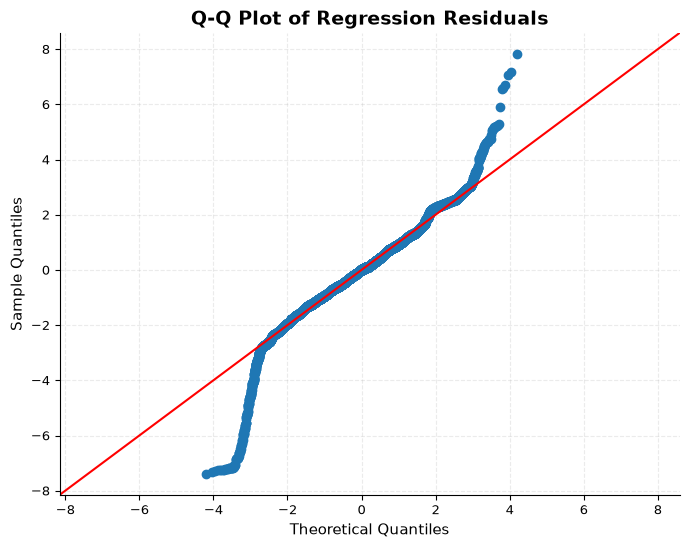

In [80]:
fig, ax = plt.subplots(figsize=(8, 6))

sm.qqplot(
    ols.resid,
    line="45",
    fit=True,
    ax=ax
)

style_plot(
    ax,
    title="Q-Q Plot of Regression Residuals",
    xlabel="Theoretical Quantiles",
    ylabel="Sample Quantiles"
)

plt.show()

__Insight:__

- __The model has very strong explanatory power, but the classical OLS error assumptions are violated, particularly homoscedasticity.__

__Multicollinearity — VIF__

In [81]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [82]:
X = ols.model.exog

# 38. **Regression Assumption Review**

The OLS model explains a very large share of the variation in `BorrowerAPR` ($R^2 \approx 0.93$), but diagnostic plots show that the classical OLS assumptions are not fully satisfied.

The next steps therefore focus on:

- multicollinearity,
- heteroscedasticity,
- residual normality,
- influential observations,
- robust inference, and
- out-of-sample predictive performance.

**Important distinction:** a high $R^2$ does not by itself prove that the model is correctly specified.


## 38.1 **Multicollinearity — VIF**

The intercept is excluded from interpretation because its VIF can be artificially large when predictors are not centred. VIF is assessed for the actual explanatory columns.


In [83]:
X_vif = pd.DataFrame(
    ols.model.exog,
    columns=ols.model.exog_names
).drop(columns="Intercept", errors="ignore")

vif_table = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
}).sort_values("VIF", ascending=False)

vif_table


,Variable,VIF
16,LogLoanAmount,238.795350
14,LogMonthlyIncome,185.286856
13,Term,17.642893
2,C(ProsperRating)[T.4.0],4.506636
3,C(ProsperRating)[T.5.0],4.124402
4,C(ProsperRating)[T.6.0],3.917109
1,C(ProsperRating)[T.3.0],3.428070
0,C(ProsperRating)[T.2.0],2.515154
12,IsBorrowerHomeowner[T.True],2.336198
5,C(ProsperRating)[T.7.0],2.118015


### VIF interpretation

As a practical rule of thumb, VIF values around 1–5 are usually manageable, while substantially larger values deserve investigation. The intercept should not be used to conclude that the model has severe multicollinearity.

The strongest structural predictor in this model is `ProsperRating`; the categorical rating indicators should be interpreted jointly because they represent the same underlying credit-rating system.


## 38.2 **Robust Standard Errors**

The Breusch–Pagan test is highly significant (`p < 0.001`), providing strong evidence that the residual variance is not constant.

Therefore, the coefficient estimates can still be useful for describing conditional associations, but conventional OLS standard errors are not reliable for inference. We use HC3 heteroscedasticity-robust standard errors.


In [84]:
ols_hc3 = ols.get_robustcov_results(cov_type="HC3")

robust_coef_table = pd.DataFrame({
    "Coefficient": ols_hc3.params,
    "Robust_SE_HC3": ols_hc3.bse,
    "t_stat": ols_hc3.tvalues,
    "p_value": ols_hc3.pvalues,
    "CI_Lower_95": ols_hc3.conf_int()[:, 0],
    "CI_Upper_95": ols_hc3.conf_int()[:, 1],
}, index=ols.model.exog_names)

robust_coef_table.sort_values("p_value")


,Coefficient,Robust_SE_HC3,t_stat,p_value,CI_Lower_95,CI_Upper_95
Intercept,0.373451,0.001438,259.787620,0.000000e+00,0.370634,0.376269
C(ProsperRating)[T.2.0],-0.026359,0.000366,-72.043039,0.000000e+00,-0.027076,-0.025642
C(ProsperRating)[T.3.0],-0.075573,0.000342,-221.037449,0.000000e+00,-0.076243,-0.074903
C(ProsperRating)[T.4.0],-0.129374,0.000329,-392.659350,0.000000e+00,-0.130020,-0.128728
C(ProsperRating)[T.5.0],-0.170898,0.000317,-539.373165,0.000000e+00,-0.171519,-0.170277
C(ProsperRating)[T.6.0],-0.215752,0.000320,-673.724425,0.000000e+00,-0.216379,-0.215124
C(ProsperRating)[T.7.0],-0.264343,0.000375,-705.430263,0.000000e+00,-0.265077,-0.263608
LogLoanAmount,-0.001767,0.000147,-12.057238,1.903278e-33,-0.002055,-0.001480
Term,0.000079,0.000008,10.256464,1.147800e-24,0.000064,0.000094
C(EmploymentStatus)[T.Other],-0.002055,0.000332,-6.194344,5.882113e-10,-0.002705,-0.001404


## 38.3 **Residual Diagnostics**

### Residuals vs fitted values

The residual plot is not a random, constant-width cloud. The vertical spread changes across fitted APR levels and several groups show visibly different dispersion. This agrees with the Breusch–Pagan result and indicates **heteroscedasticity**.

The clustering is also consistent with the strong role of `ProsperRating`: borrowers in different rating groups occupy different APR ranges.


In [99]:
def influence_diagnostics(model):
    """
    Calculate robust OLS influence diagnostics.

    Returns:
        leverage
        studentized residuals
        Cook's distance

    Handles observations with leverage >= 1 safely.
    """

    # Basic quantities
    X = np.asarray(model.model.exog, dtype=float)
    residuals = np.asarray(model.resid, dtype=float)

    n, p = X.shape
    mse = model.mse_resid

    # Hat matrix diagonal
    XtX_inv = np.linalg.pinv(X.T @ X)
    leverage = np.sum((X @ XtX_inv) * X, axis=1)

    # Values where studentization is mathematically valid
    denominator = 1 - leverage

    valid = denominator > 0

    # Initialize with NaN
    studentized_residual = np.full(n, np.nan)
    cooks_distance = np.full(n, np.nan)

    # Studentized residuals
    studentized_residual[valid] = (
        residuals[valid]
        / np.sqrt(mse)
        / np.sqrt(denominator[valid])
    )

    # Cook's distance
    cooks_distance[valid] = (
        (residuals[valid] ** 2)
        / (p * mse)
        * (leverage[valid] / denominator[valid])
    )

    diagnostics = pd.DataFrame(
        {
            "leverage": leverage,
            "studentized_residual": studentized_residual,
            "cooks_distance": cooks_distance,
        },
        index=model.model.data.row_labels,
    )

    return diagnostics

In [100]:
influence_df = influence_diagnostics(ols)

influence_df.head()

,leverage,studentized_residual,cooks_distance
1,0.000101,-0.859377,0.000004
3,0.000143,-0.668394,0.000004
4,0.000138,-1.518628,0.000018
5,0.000106,-1.450087,0.000012
6,0.000153,-0.961488,0.000008


In [101]:
n = len(influence_df)
p = ols.df_model + 1

leverage_threshold = 2 * p / n
cook_threshold = 4 / n

influential = influence_df[
    (influence_df["leverage"] > leverage_threshold) |
    (influence_df["cooks_distance"] > cook_threshold) |
    (influence_df["studentized_residual"].abs() > 3)
]

influential.shape

(3348, 3)

In [102]:
influential.sort_values(
    "cooks_distance",
    ascending=False
).head(10)

,leverage,studentized_residual,cooks_distance
92486,0.005243,-7.411283,0.015999
113261,0.005225,-7.189091,0.015004
21651,0.005108,-6.490423,0.011955
60987,0.003341,-7.301244,0.009893
109771,0.003291,-7.203824,0.009489
50424,0.003330,-7.092647,0.009306
38072,0.005156,-4.536882,0.005896
40510,0.004844,4.527705,0.005517
29210,0.003314,-5.171610,0.004924
88774,0.005213,3.943068,0.004503


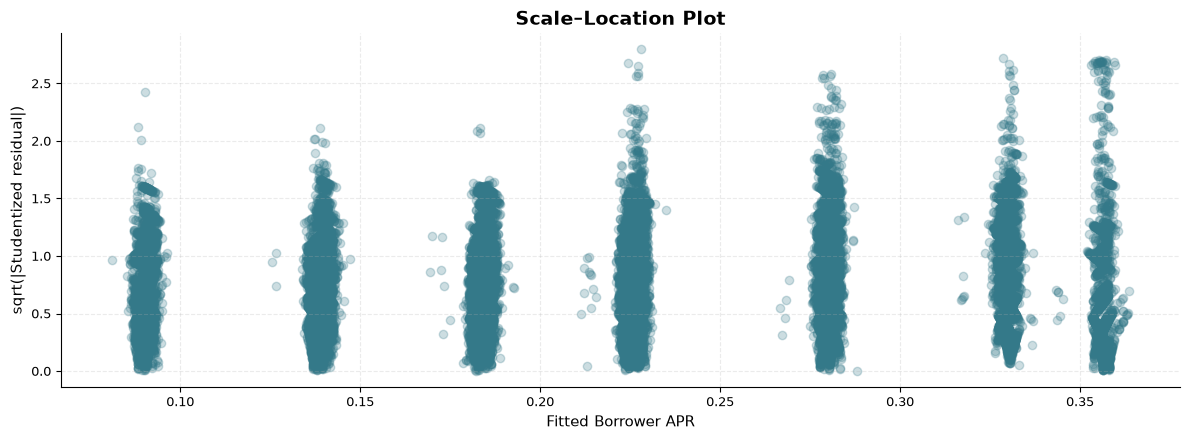

In [106]:
# Get OLS influence object
influence = ols.get_influence()

# Residuals
residuals = np.asarray(ols.resid, dtype=float)

# Residual standard deviation
sigma = np.sqrt(ols.mse_resid)

# Leverage values
leverage = np.asarray(
    influence.hat_matrix_diag,
    dtype=float
)

# Calculate internally studentized residuals safely
with np.errstate(divide="ignore", invalid="ignore"):
    studentized_residual = (
        residuals
        / sigma
        / np.sqrt(np.maximum(1 - leverage, np.finfo(float).eps))
    )

# Cook's distance can still be obtained separately
with np.errstate(divide="ignore", invalid="ignore"):
    cooks_distance = (
        (studentized_residual ** 2)
        * leverage
        / (
            ols.df_model + 1
        )
        / np.maximum(1 - leverage, np.finfo(float).eps)
    )

# Store diagnostics
model_data = model_data.copy()

model_data["StudentizedResidual"] = studentized_residual
model_data["Leverage"] = leverage
model_data["CooksDistance"] = cooks_distance

# Scale–Location plot
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.scatter(
    ols.fittedvalues,
    np.sqrt(np.abs(studentized_residual)),
    alpha=0.25,
    color="#347989"
)

style_plot(
    ax,
    title="Scale–Location Plot",
    xlabel="Fitted Borrower APR",
    ylabel="sqrt(|Studentized residual|)"
)

plt.tight_layout()
plt.show()

__Insights__
>__The Scale–Location diagnostic indicates non-constant residual variance across fitted Borrower APR values. This is consistent with the significant Breusch–Pagan test, suggesting that conventional OLS standard errors may be unreliable. HC3 heteroscedasticity-robust standard errors are therefore used for inference.__

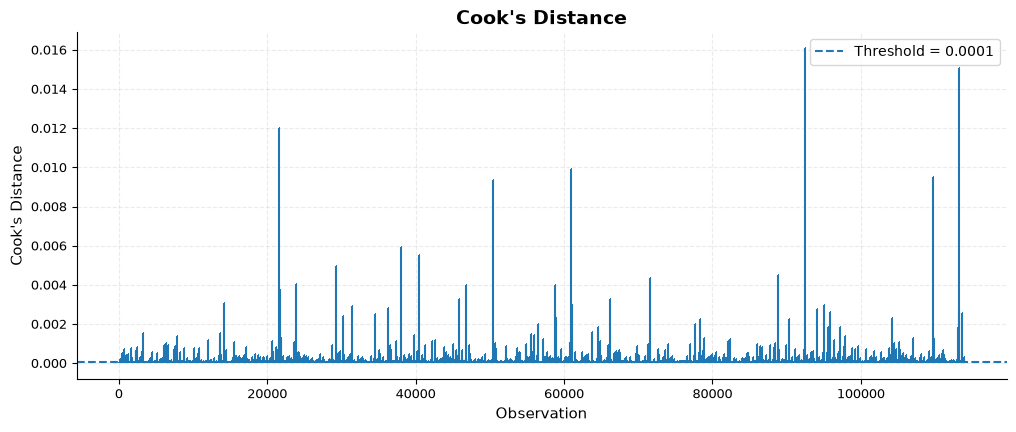

In [97]:
fig, ax = plt.subplots(figsize=(12, 4.5))

ax.stem(
    influence_df.index,
    influence_df["cooks_distance"].fillna(0),
    markerfmt=",",
    basefmt=" "
)

ax.axhline(
    cook_threshold,
    linestyle="--",
    label=f"Threshold = {cook_threshold:.4f}"
)

style_plot(
    ax,
    title="Cook's Distance",
    xlabel="Observation",
    ylabel="Cook's Distance"
)

ax.legend()
plt.show()

### Q–Q plot interpretation

The Q–Q plot follows the reference line reasonably well around the centre but departs strongly in both tails. This indicates **non-normal residual tails and influential/extreme observations**.

With more than 77,000 observations, minor departures from normality are less important for point estimation than the heteroscedasticity and model specification issues. For inference, robust standard errors are therefore more important than trying to force the residuals to be perfectly normal.


In [105]:
# Influence diagnostics: observations with unusually large Cook's distance
cook_cutoff = 4 / len(model_data)
high_influence = model_data.loc[
    model_data["CooksDistance"] > cook_cutoff,
    ["BorrowerAPR", "Fitted", "Residuals", "Leverage", "CooksDistance"]
].sort_values("CooksDistance", ascending=False)

print(f"Cook's-distance screening threshold: {cook_cutoff:.6g}")
print(f"Observations above threshold: {len(high_influence):,}")
high_influence.head(10)


Cook's-distance screening threshold: 5.1575e-05
Observations above threshold: 2,552


,BorrowerAPR,Fitted,Residuals,Leverage,CooksDistance
21386,0.28800,0.288000,-1.110223e-15,1.000000,3181.355132
92486,0.17426,0.328707,-1.544470e-01,0.005243,0.016084
113261,0.20392,0.353738,-1.498180e-01,0.005225,0.015083
21651,0.14314,0.278406,-1.352660e-01,0.005108,0.012016
60987,0.20504,0.357339,-1.522993e-01,0.003341,0.009927
109771,0.20918,0.359451,-1.502709e-01,0.003291,0.009520
50424,0.21172,0.359669,-1.479489e-01,0.003330,0.009337
38072,0.23361,0.328160,-9.455025e-02,0.005156,0.005926
40510,0.32175,0.227376,9.437379e-02,0.004844,0.005543
29210,0.12106,0.228938,-1.078780e-01,0.003314,0.004940


# 39. **Statistical Model — Key Findings**

The OLS model has an $R^2$ of approximately **0.93**, meaning the selected predictors explain about 93% of the observed variation in borrower APR within the estimation sample.

The most important result is the monotonic relationship with `ProsperRating`: compared with the reference rating, higher rating categories are associated with substantially lower APR. This relationship is large, highly statistically significant, and visible directly in the boxplot.

Other variables have much smaller conditional associations:

- `Term` is positively associated with APR.
- `LogLoanAmount` is negatively associated with APR.
- `LogMonthlyIncome` is negatively associated with APR, but the magnitude is small.
- Home ownership has a small positive conditional coefficient in this specification.
- `DebtToIncomeRatio` is not statistically significant in the fitted OLS model after controlling for the other variables.
- Some employment-status differences are statistically significant, but their economic magnitudes are small relative to the rating effects.

**Portfolio interpretation:** credit rating is the dominant pricing signal in this model; borrower/loan characteristics add incremental information around that core relationship.


# 40. **Out-of-Sample Prediction**

A strong in-sample $R^2$ is not sufficient. We now evaluate models on a **chronological holdout** so that earlier loans are used for training and later loans are used for testing.

This is more realistic for loan-pricing analysis than randomly mixing future observations into the training set.

The preprocessing pipeline also prevents data leakage by fitting imputers and encoders on the training data only.


In [87]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modeling dataset: only variables known at listing time.
ml_features = [
    "ProsperRating",
    "Term",
    "StatedMonthlyIncome",
    "DebtToIncomeRatio",
    "LoanOriginalAmount",
    "EmploymentStatus",
    "IsBorrowerHomeowner",
    "ListingYear",
    "ListingMonth",
]

target = "BorrowerAPR"

ml_data = loans[ml_features + [target, "ListingCreationDate"]].copy()
ml_data = ml_data.dropna(subset=[target, "ListingCreationDate"]).sort_values("ListingCreationDate")

split_idx = int(len(ml_data) * 0.80)
train = ml_data.iloc[:split_idx].copy()
test = ml_data.iloc[split_idx:].copy()

X_train = train[ml_features]
X_test = test[ml_features]
y_train = train[target]
y_test = test[target]

categorical_features = [
    "ProsperRating",
    "EmploymentStatus",
    "IsBorrowerHomeowner",
]
numeric_features = [
    "Term",
    "StatedMonthlyIncome",
    "DebtToIncomeRatio",
    "LoanOriginalAmount",
    "ListingYear",
    "ListingMonth",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)

ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0)),
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

ridge_metrics = {
    "Model": "Ridge",
    "MAE": mean_absolute_error(y_test, ridge_pred),
    "RMSE": mean_squared_error(y_test, ridge_pred) ** 0.5,
    "R2": r2_score(y_test, ridge_pred),
}

pd.DataFrame([ridge_metrics])


,Model,MAE,RMSE,R2
0,Ridge,0.032577,0.037121,0.615175


In [88]:
# A nonlinear benchmark.
# HistGradientBoosting requires a fully numeric design matrix.

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# OneHotEncoder may return sparse output; convert only this relatively small
# feature matrix to dense form for the gradient-boosting estimator.
X_train_encoded = X_train_encoded.toarray() if hasattr(X_train_encoded, "toarray") else X_train_encoded
X_test_encoded = X_test_encoded.toarray() if hasattr(X_test_encoded, "toarray") else X_test_encoded

hgb_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42,
)

hgb_model.fit(X_train_encoded, y_train)
hgb_pred = hgb_model.predict(X_test_encoded)

hgb_metrics = {
    "Model": "HistGradientBoosting",
    "MAE": mean_absolute_error(y_test, hgb_pred),
    "RMSE": mean_squared_error(y_test, hgb_pred) ** 0.5,
    "R2": r2_score(y_test, hgb_pred),
}

model_comparison = pd.DataFrame([ridge_metrics, hgb_metrics]).sort_values("RMSE")
model_comparison


,Model,MAE,RMSE,R2
1,HistGradientBoosting,0.015555,0.020197,0.886077
0,Ridge,0.032577,0.037121,0.615175


## 40.1 **Prediction Diagnostics**

Use the following plots to determine whether the model generalizes well and whether errors are concentrated in particular APR ranges.


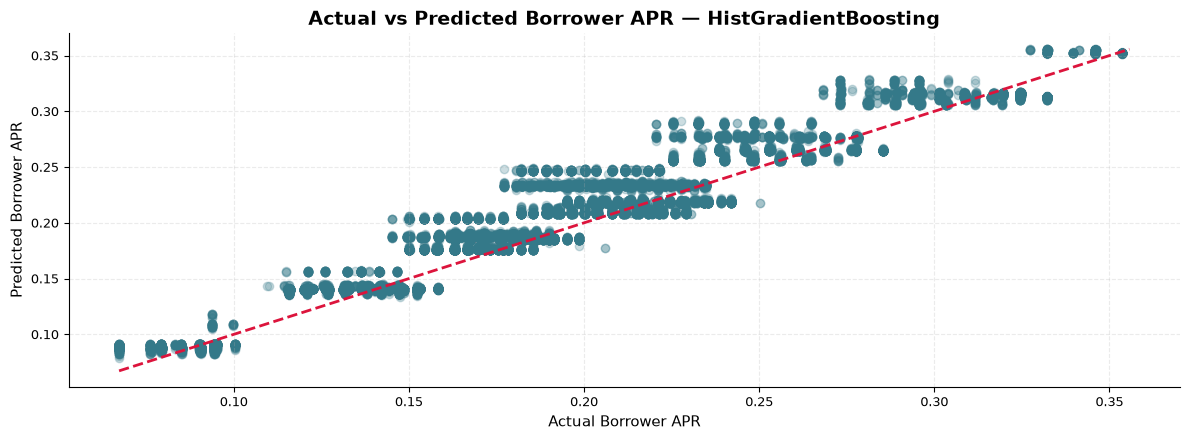

In [91]:
best_pred = (
    hgb_pred if hgb_metrics["RMSE"] < ridge_metrics["RMSE"]
    else ridge_pred
)

best_name = (
    "HistGradientBoosting"
    if hgb_metrics["RMSE"] < ridge_metrics["RMSE"]
    else "Ridge"
)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.scatter(y_test, best_pred, alpha=0.25, color="#347989")
lims = [
    min(y_test.min(), best_pred.min()),
    max(y_test.max(), best_pred.max())
]
ax.plot(lims, lims, color="crimson", linestyle="--", linewidth=2)

style_plot(
    ax,
    title=f"Actual vs Predicted Borrower APR — {best_name}",
    xlabel="Actual Borrower APR",
    ylabel="Predicted Borrower APR"
)
plt.tight_layout()
plt.show()


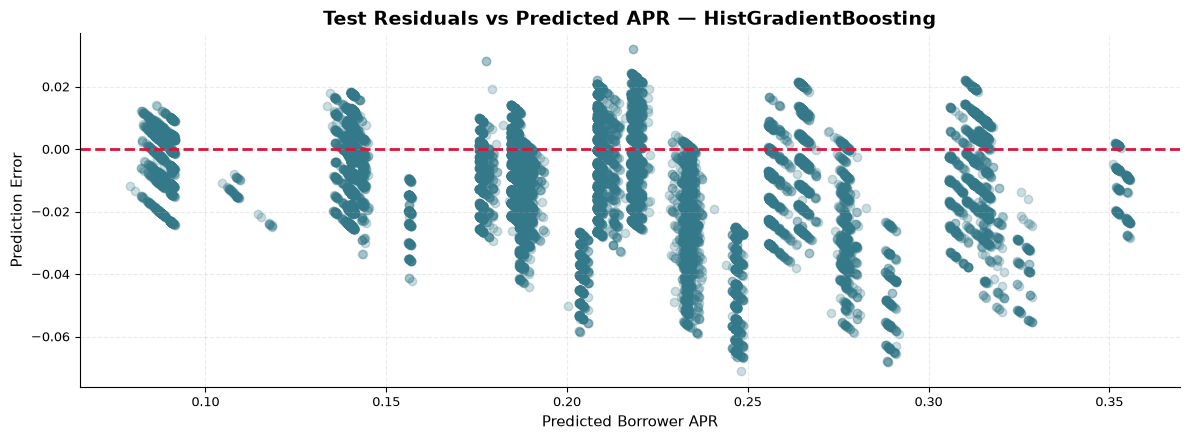

In [92]:
test_residuals = y_test - best_pred

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.scatter(best_pred, test_residuals, alpha=0.25, color="#347989")
ax.axhline(0, color="crimson", linestyle="--", linewidth=2)

style_plot(
    ax,
    title=f"Test Residuals vs Predicted APR — {best_name}",
    xlabel="Predicted Borrower APR",
    ylabel="Prediction Error"
)
plt.tight_layout()
plt.show()


# 41. **Model Selection and Interpretation**

The statistical and machine-learning models answer slightly different questions:

| Model | Main purpose |
|---|---|
| OLS | Explain conditional associations and quantify coefficients |
| Ridge | Provide a regularized linear prediction benchmark |
| HistGradientBoosting | Capture nonlinear relationships and interactions |


# 42. **Executive Insights**

### 1. Credit rating dominates APR pricing
The Prosper Rating boxplot shows a clear monotonic decline in borrower APR as the rating improves. The OLS model confirms that these differences remain very large after controlling for income, DTI, loan amount, term, employment status, and home ownership.

### 2. APR changed materially over time
Average APR increased from 2007 through 2011, peaked around 2011, and then declined sharply through 2014. This suggests that market conditions, platform pricing policy, borrower mix, or changes in underwriting may have affected observed rates.

### 3. Numerical correlations alone miss the main story
The correlation matrix shows only a moderate negative relationship between APR and loan amount (about -0.32) and investors (about -0.31), while the strongest pricing pattern comes from the categorical credit-rating structure. This is why bivariate correlations should not be treated as a complete feature-importance analysis.

### 4. The regression is highly explanatory but not perfectly specified
The OLS model achieves $R^2 \approx 0.93$, but the residual-vs-fitted plot shows changing variance and the Q–Q plot shows heavy tail departures. The significant Breusch–Pagan test confirms heteroscedasticity.

### 5. Statistical significance is not the same as economic importance
With 77,557 observations, very small coefficients can become statistically significant. The portfolio should therefore report coefficient magnitude and confidence intervals alongside p-values.

### 6. Prediction should be validated on future-like data
A chronological holdout provides a stronger test of practical generalization than an entirely random split. The final model comparison should therefore focus on the test-set MAE/RMSE/R² produced above.


# 43. **Limitations and Next Steps**

### Limitations
- The analysis is observational; it does not establish causality.
- The original dataset contains substantial missingness in several variables.
- The OLS model uses complete cases, which can reduce the usable sample and potentially introduce selection bias.
- The regression diagnostics show heteroscedasticity and non-normal residual tails.
- Some important pricing variables are intentionally excluded because they are downstream of the pricing decision and would create target leakage.

### Next steps
1. Add formal time-based model monitoring.
2. Tune the nonlinear model with cross-validation inside the training period.
3. Examine performance by Prosper Rating and loan term.
4. Add bootstrap or robust uncertainty analysis where appropriate.
5. Build a small dashboard showing APR distribution, rating effects, time trends, and model predictions.
